In [1]:
import numpy as np
import pandas as pd 
import cv2
import matplotlib.pyplot as plt
import easyocr
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


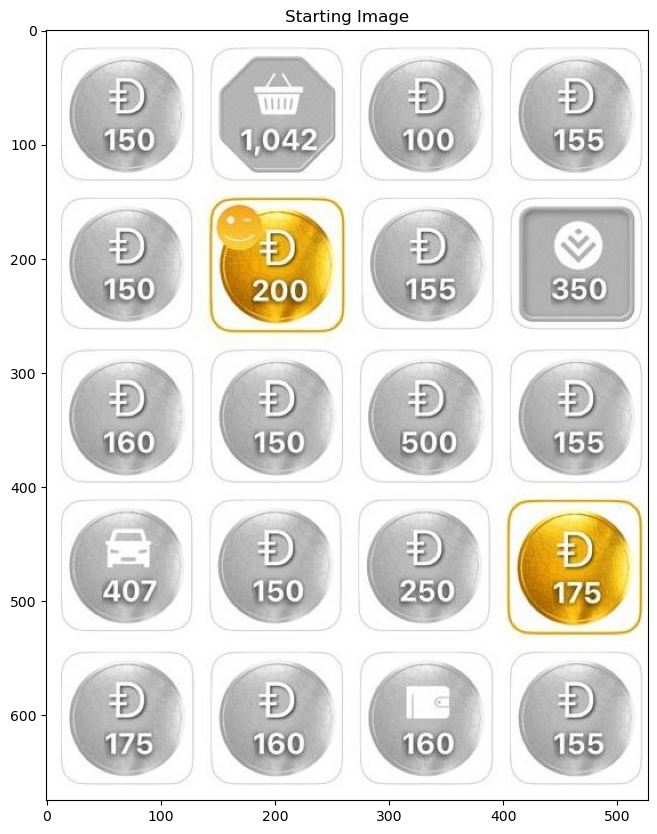

In [112]:
path = '../data/images/Image4.jpeg'
img = cv2.imread(path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.title("Starting Image")
plt.show()

In [114]:
#test_tile = img_rgb[1:150, 50:150]
#plt.imshow(test_tile)
#plt.show

In [116]:
#test_tile2 = img_rgb[150:275, 180:280]
#plt.imshow(test_tile2)
#plt.show

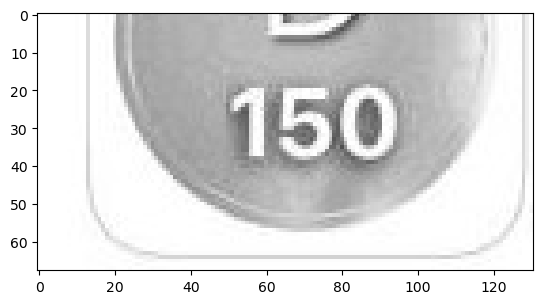

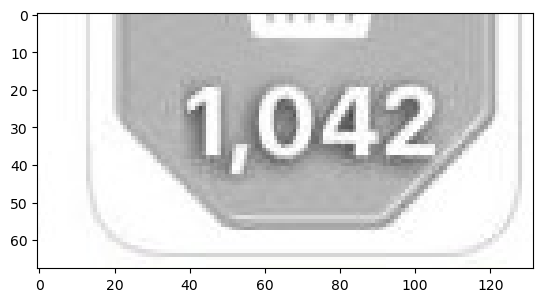

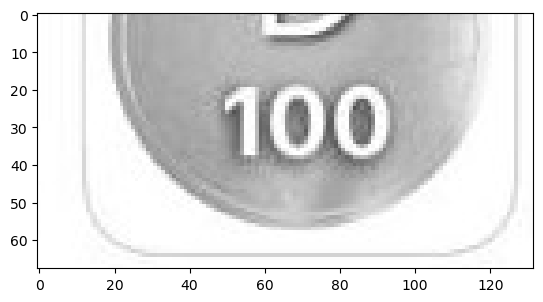

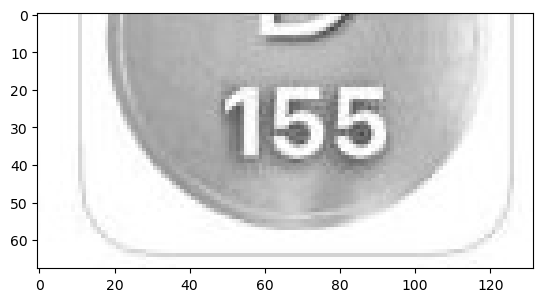

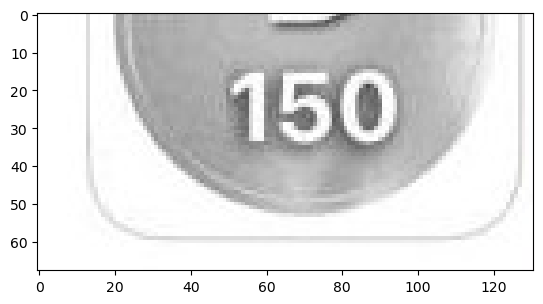

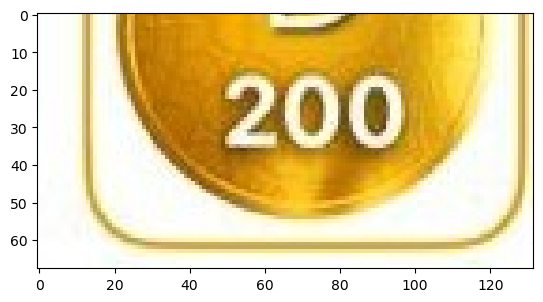

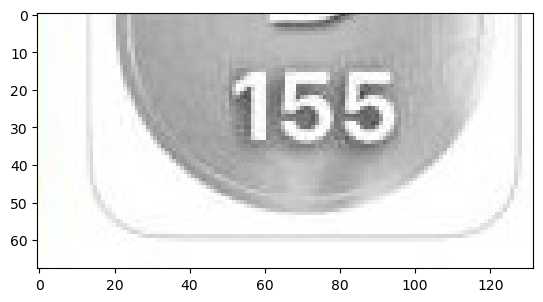

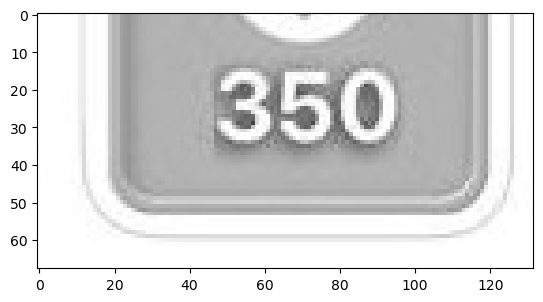

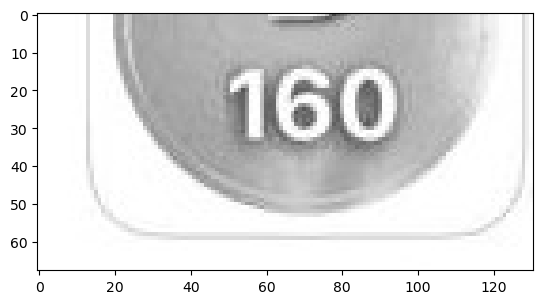

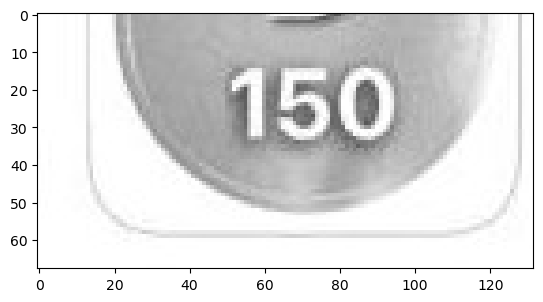

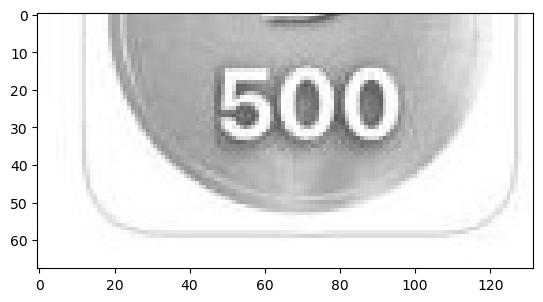

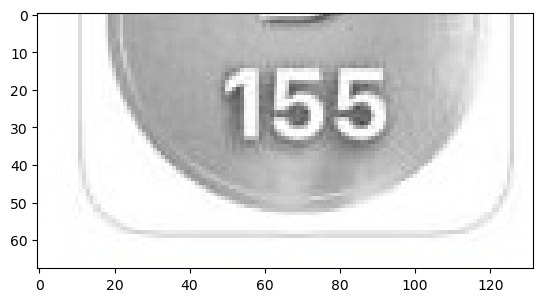

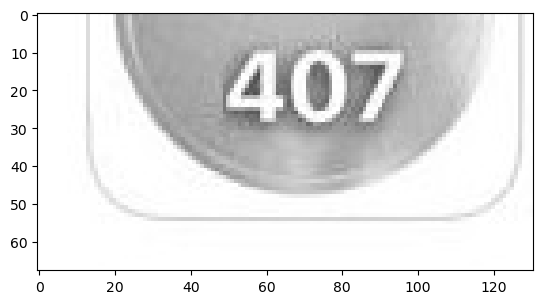

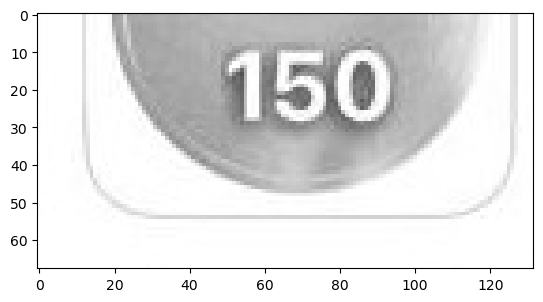

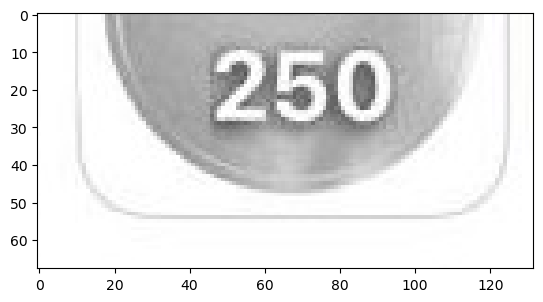

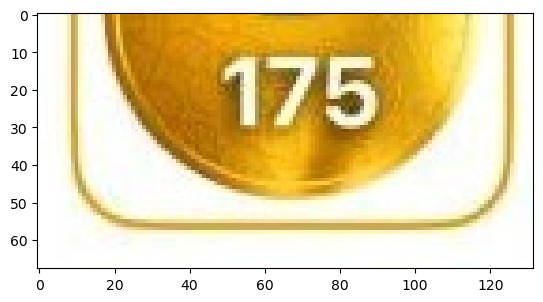

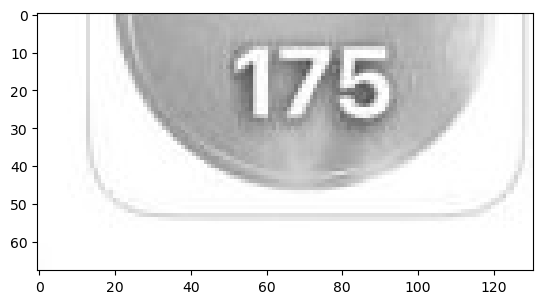

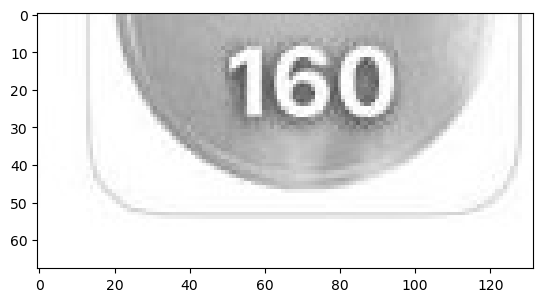

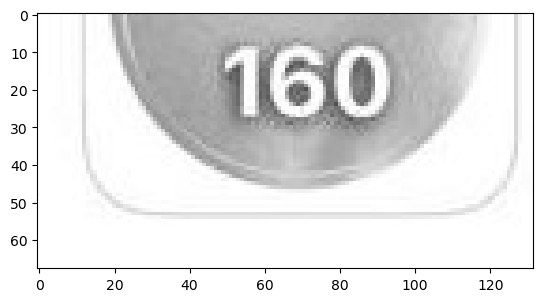

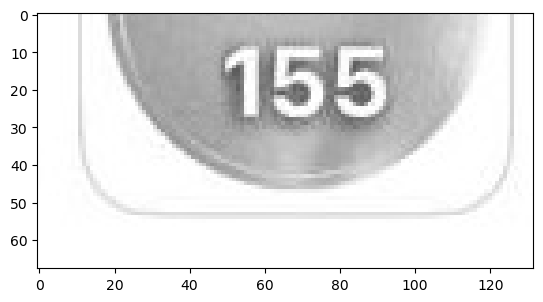

In [118]:
height, width, _ = img_rgb.shape
rows = 5 
cols = 4

## split image intp 5 by 4 grid - requires cropped screenshot to be uploaded 
row_step = height / rows 
col_step = width / cols
numbers = []
for r in range(rows):
    for c in range(cols):
        y1, y2 = r * row_step, (r +1) * row_step
        x1, x2 = c * col_step, (c +1) * col_step

        tile = img_rgb[int(y1):int(y2), int(x1):int(x2)]
        ## exract bottom part with number
        t_h, t_w, _ = tile.shape
        number = tile[int(t_h * 0.5):t_h, 0:t_w]
        numbers.append(number)
        plt.imshow(number)
        plt.show()
        

        

In [120]:
def number_extractor(image):
    gray_tile = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_tile, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    padding = 15
    padded_tile = cv2.copyMakeBorder(
        thresh, 
        padding, padding, padding, padding, 
        cv2.BORDER_CONSTANT, 
        value=[255, 255, 255]
    )
    upscaled = cv2.resize(padded_tile, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    results = reader.readtext(upscaled)
    if not results:
        return None 
    text = results[0][1]
    clean = ''.join(filter(str.isdigit, text))
    return int(clean) if clean else None

vals=[]
for i in range(20):
    value = number_extractor(numbers[i])
    vals.append(value)
    print(f'OCR got {value}')



C:\Users\ethan\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR got 150
OCR got 1042
OCR got 100
OCR got 155
OCR got 150
OCR got 200
OCR got 155
OCR got 350
OCR got 160
OCR got 150
OCR got 500
OCR got 155
OCR got 407
OCR got 150
OCR got 250
OCR got 175
OCR got 175
OCR got 160
OCR got 160
OCR got 155


In [122]:
vals

[150,
 1042,
 100,
 155,
 150,
 200,
 155,
 350,
 160,
 150,
 500,
 155,
 407,
 150,
 250,
 175,
 175,
 160,
 160,
 155]

In [124]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

from src.database import save_results


In [126]:
#board_values = vals 

# Path to the image you just processed
#image_path = "../data/raw_images/test_board.png"

#clean_values = np.ascontiguousarray(board_values).tolist()

# Now pass the clean version
#try:
   # board_id = save_results(clean_values, image_path)
   # print(f"Successfully populated database! Board ID: {board_id}")
#except Exception as e:
 3   print(f"Database save failed: {e}")

Successfully populated database! Board ID: 4


In [129]:
from src.database import get_history_df
df = get_history_df()
df

,id,board_id,grid_index,reward_amount
0,1,1,0,125
1,2,1,1,125
2,3,1,2,231
3,4,1,3,160
4,5,1,4,175
...,...,...,...,...
75,76,4,15,175
76,77,4,16,175
77,78,4,17,160
78,79,4,18,160


(array([ 0., 55., 11.,  4.,  3.,  3.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,
         0.]),
 array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,
         900., 1000., 1100., 1200., 1300., 1400.]),
 <BarContainer object of 14 artists>)

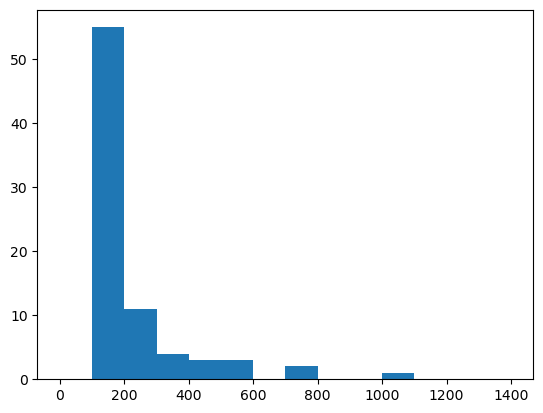

In [225]:
bins = np.arange(0, 1500, 100)
plt.hist(df.reward_amount, bins=bins)

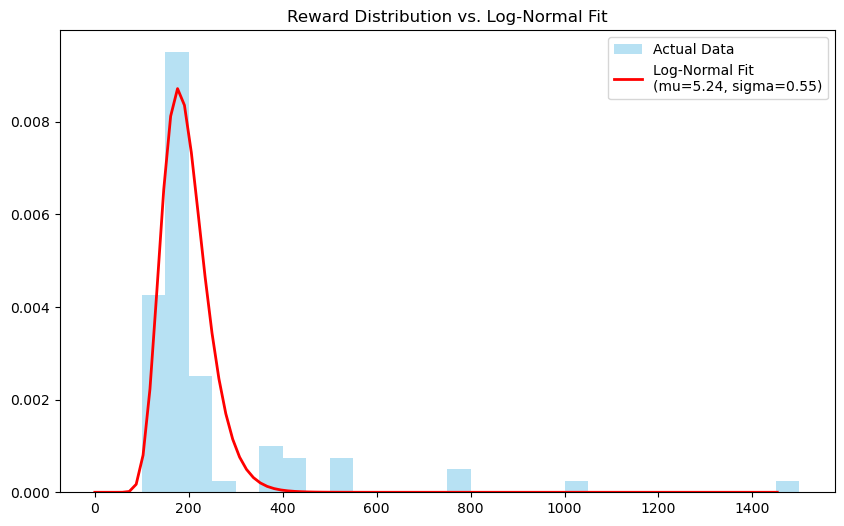

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. Fit the Log-Normal parameters to your data
# s is the shape parameter (sigma), loc is the offset, scale is exp(mu)
shape, loc, scale = lognorm.fit(df['reward_amount'], floc=0) # We lock loc to 0 for money

# 2. Create the X-axis range
x = np.linspace(0, df['reward_amount'].max(), 100)
pdf = lognorm.pdf(x, 0.25, loc, scale)

# 3. Plot
plt.figure(figsize=(10, 6))
# Density=True is required to compare a histogram to a PDF curve
plt.hist(df['reward_amount'], bins=np.arange(0, df['reward_amount'].max() + 50, 50), 
         density=True, alpha=0.6, color='skyblue', label='Actual Data')
plt.plot(x, pdf, 'r-', lw=2, label=f'Log-Normal Fit\n(mu={np.log(scale):.2f}, sigma={shape:.2f})')

plt.title("Reward Distribution vs. Log-Normal Fit")
plt.legend()
plt.show()

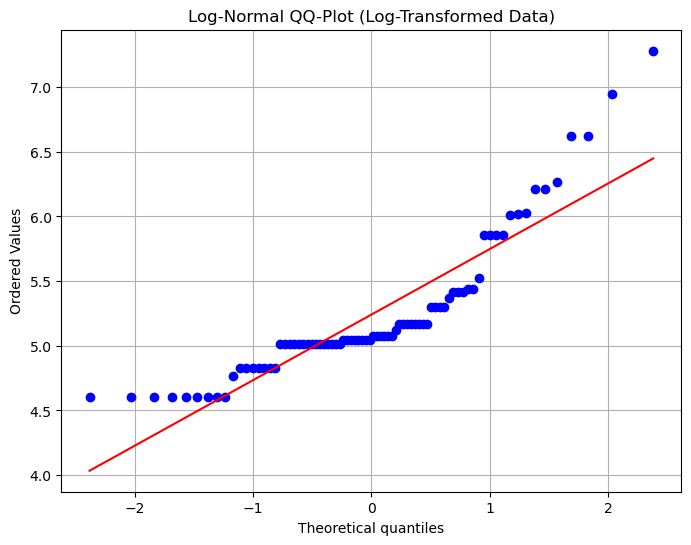

In [150]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))
# We use the log of the data to compare it against a Normal distribution
# because Log(LogNormal) = Normal. This is the standard way to check Log-Normality.
stats.probplot(np.log(df['reward_amount']), dist="norm", plot=plt)

plt.title("Log-Normal QQ-Plot (Log-Transformed Data)")
plt.grid(True)
plt.show()

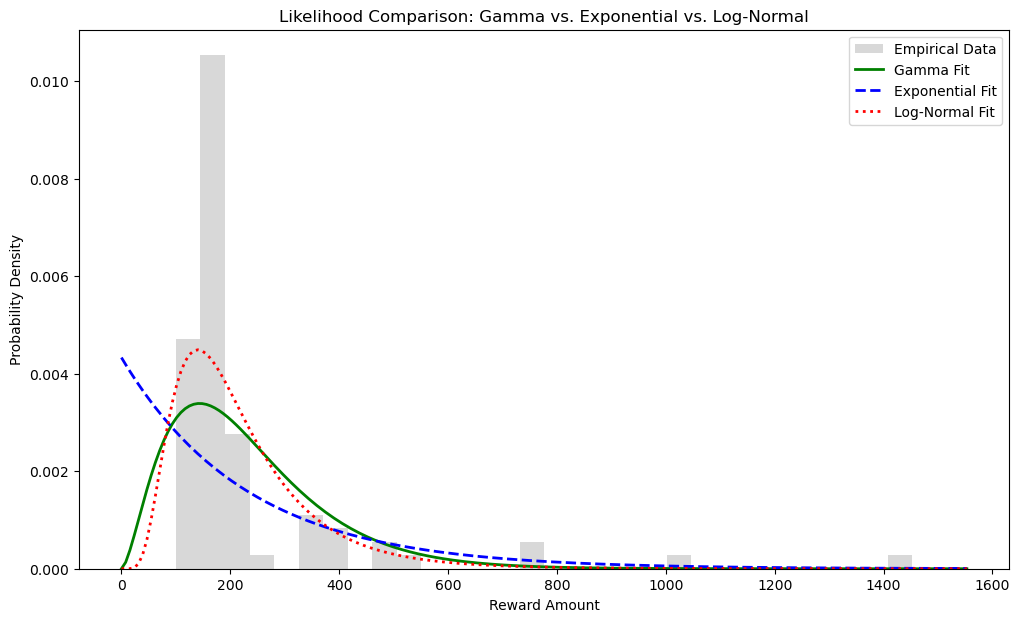

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, expon, lognorm

# 1. Fit the distributions
# Gamma fit
g_shape, g_loc, g_scale = gamma.fit(df['reward_amount'], floc=0)
# Exponential fit
e_loc, e_scale = expon.fit(df['reward_amount'], floc=0)
# Log-Normal fit (for comparison)
l_shape, l_loc, l_scale = lognorm.fit(df['reward_amount'], floc=0)

# 2. X-axis for plotting
x = np.linspace(0, df['reward_amount'].max() + 100, 200)

# 3. Plotting
plt.figure(figsize=(12, 7))
plt.hist(df['reward_amount'], bins=30, density=True, alpha=0.3, color='gray', label='Empirical Data')

plt.plot(x, gamma.pdf(x, g_shape, g_loc, g_scale), 'g-', lw=2, label='Gamma Fit')
plt.plot(x, expon.pdf(x, e_loc, e_scale), 'b--', lw=2, label='Exponential Fit')
plt.plot(x, lognorm.pdf(x, l_shape, l_loc, l_scale), 'r:', lw=2, label='Log-Normal Fit')

plt.title("Likelihood Comparison: Gamma vs. Exponential vs. Log-Normal")
plt.xlabel("Reward Amount")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

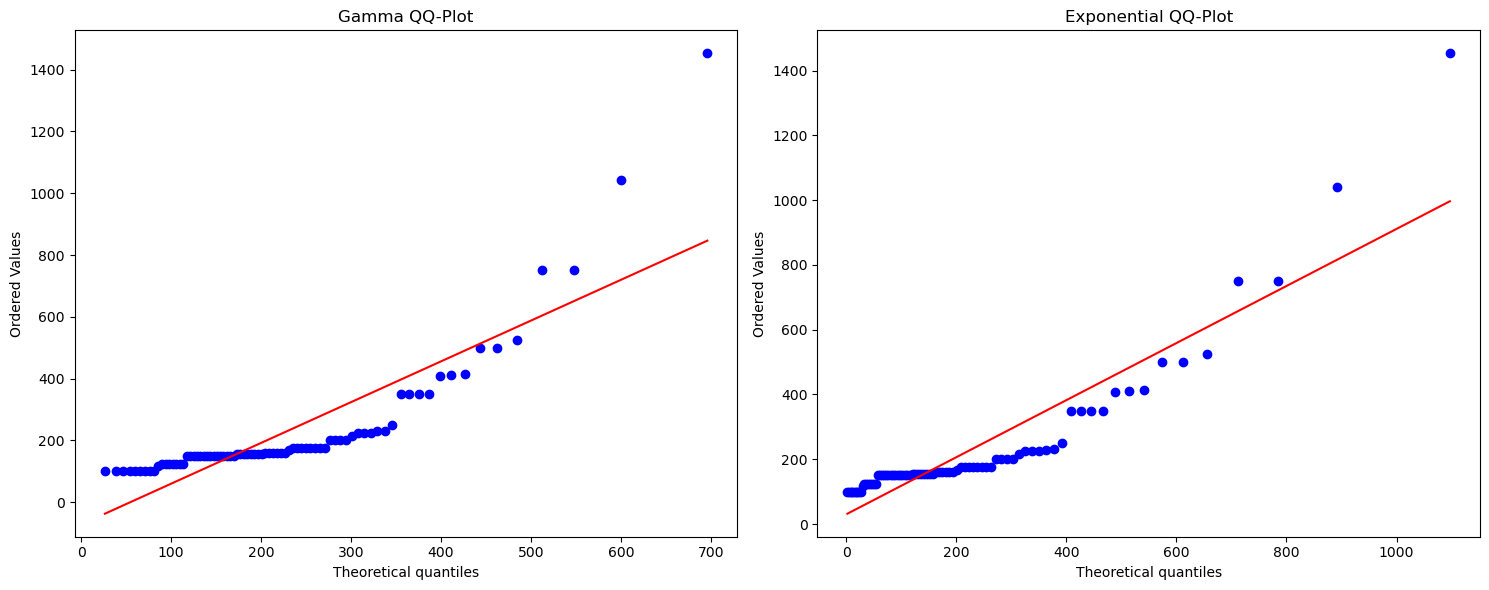

In [154]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gamma QQ-Plot
stats.probplot(df['reward_amount'], dist=stats.gamma(g_shape, loc=g_loc, scale=g_scale), plot=axes[0])
axes[0].set_title("Gamma QQ-Plot")

# Exponential QQ-Plot
stats.probplot(df['reward_amount'], dist=stats.expon(loc=e_loc, scale=e_scale), plot=axes[1])
axes[1].set_title("Exponential QQ-Plot")

plt.tight_layout()
plt.show()

In [23]:
import pymc as pm
import arviz as az

In [65]:
import pymc as pm
import numpy as np
import arviz as az

def run_bandit_model(df):
    # Prepare indices and observed values
    square_idx = df['grid_index'].values
    rewards = df['reward_amount'].values

    with pm.Model() as model:
        # --- Priors ---
        # We use a Normal prior for the log-mean. 
        # Since log(170) is ~5.1, we center our prior there.
        mu = pm.Normal("mu", mu=5.1, sigma=1.0, shape=20)
        
        # Sigma represents the spread/volatility of the rewards
        sigma = pm.HalfNormal("sigma", sigma=1.0, shape=20)
        
        # --- Likelihood ---
        # LogNormal is perfect for right-skewed positive data (like money)
        y_obs = pm.LogNormal("y_obs", mu=mu[square_idx], sigma=sigma[square_idx], observed=rewards)
        
        # --- Inference ---
        # Draws: number of samples. Tune: 'burn-in' steps for the sampler.
        trace = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True)
        
    return trace

def get_recommendations(trace):
    # Extract the posterior samples for 'mu'
    # To get the Expected Value of a LogNormal: EV = exp(mu + sigma^2 / 2)
    post_mu = trace.posterior["mu"].values
    post_sigma = trace.posterior["sigma"].values
    
    # Calculate EV for every sample, then take the mean
    ev_samples = np.exp(post_mu + (post_sigma**2) / 2)
    expected_values = ev_samples.mean(axis=(0, 1)) # average across chains and draws
    
    # Uncertainty: standard deviation of the EVs
    uncertainty = ev_samples.std(axis=(0, 1))
    
    return expected_values.reshape(5, 4), uncertainty.reshape(5, 4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 114 seconds.
There were 220 divergences after tuning. Increase `target_accept` or reparameterize.


array([<Axes: title={'center': 'mu\n0'}>,
       <Axes: title={'center': 'mu\n10'}>], dtype=object)

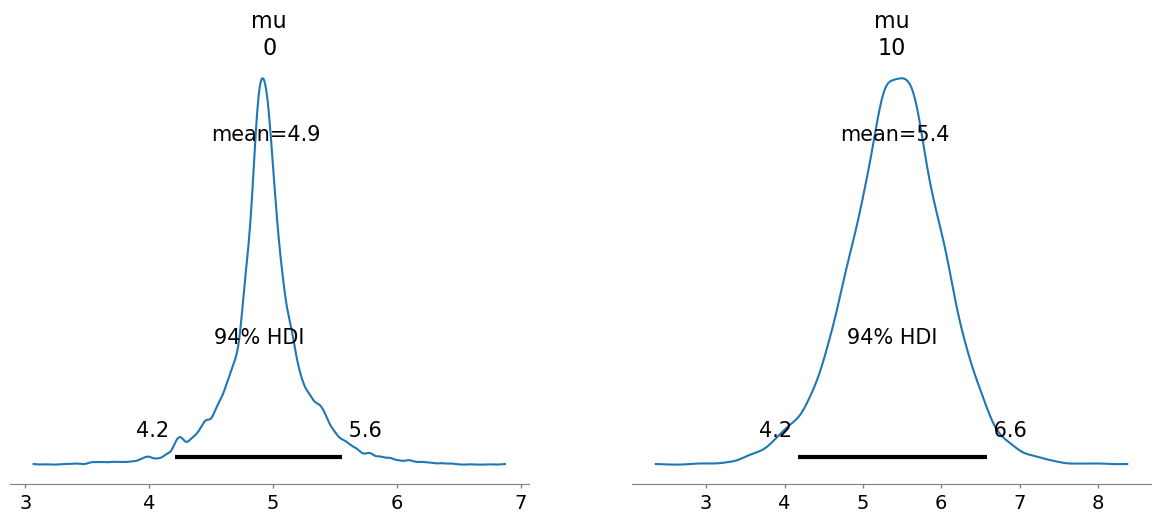

In [67]:

# 1. Run the math
trace = run_bandit_model(df)

# 2. Get the grid and uncertainty
ev_grid, uncertainty_grid = get_recommendations(trace)

# 3. Quick peek at square 0 vs square 10
az.plot_posterior(trace, var_names=["mu"], coords={"mu_dim_0": [0, 10]})

In [80]:
print(np.exp(4.2))
print(np.exp(4.9))
print(np.exp(5.6))
print(np.exp(4.2))
print(np.exp(5.4))
print(np.exp(6.6))

66.68633104092515
134.28977968493552
270.42640742615254
66.68633104092515
221.40641620418717
735.0951892419727


In [71]:
import pymc as pm
import numpy as np
import arviz as az

def run_hierarchical_bandit(df):
    # Data prep
    square_idx = df['grid_index'].values
    rewards = df['reward_amount'].values
    n_squares = 20

    with pm.Model() as model:
        # --- HYPER-PRIORS (The "Global" Board Knowledge) ---
        # This is the average log-reward for the entire game
        mu_global = pm.Normal("mu_global", mu=5.1, sigma=0.5)
        # This is how much squares tend to differ from each other
        tau_global = pm.Exponential("tau_global", lam=1.0)
        
        # --- PRIORS (The "Individual" Square Knowledge) ---
        # Now, each square's mu is drawn from the global distribution.
        # This is where 'Partial Pooling' happens.
        mu_square = pm.Normal("mu_square", mu=mu_global, sigma=tau_global, shape=n_squares)
        
        # Individual volatility for each square
        sigma_square = pm.HalfNormal("sigma_square", sigma=0.5, shape=n_squares)
        
        # --- LIKELIHOOD ---
        y_obs = pm.LogNormal("y_obs", 
                             mu=mu_square[square_idx], 
                             sigma=sigma_square[square_idx], 
                             observed=rewards)
        
        # --- INFERENCE ---
        # With hierarchical models, we increase target_accept to handle the complex geometry
        trace = pm.sample(2000, tune=2000, target_accept=0.99, return_inferencedata=True)
        
    return trace

In [73]:

# 1. Run the math
trace = run_hierarchical_bandit(df)

# 2. Get the grid and uncertainty
ev_grid, uncertainty_grid = get_recommendations(trace)

# 3. Quick peek at square 0 vs square 10
az.plot_posterior(trace, var_names=["mu"], coords={"mu_dim_0": [0, 10]})

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, tau_global, mu_square, sigma_square]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1154 seconds.
There were 1952 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


KeyError: 'mu'

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

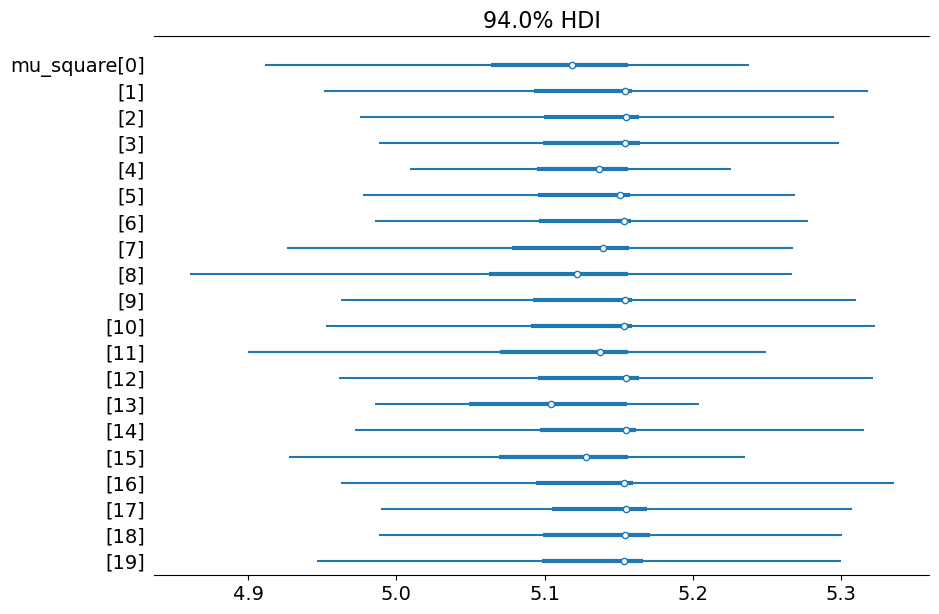

In [76]:
# Compare the estimated means of the 20 squares
az.plot_forest(trace, var_names=["mu_square"], combined=True, figsize=(10, 7))

array([[<Axes: title={'center': 'mu_square'}>,
        <Axes: title={'center': 'mu_square'}>]], dtype=object)

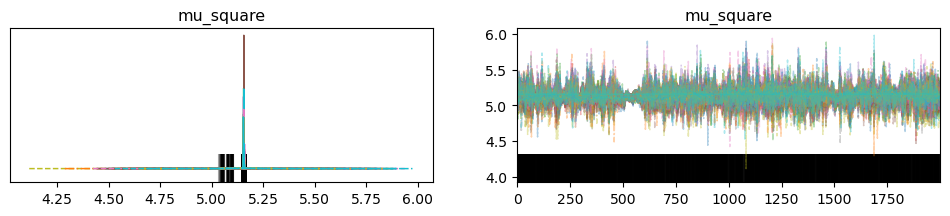

In [ ]:
np.exp(4.2)
np.exp(4.9)
np.exp(5.6)
np.exp(4.2)
np.exp(5.4)
np.exp(6.6)

In [211]:

def run_hierarchical_bandit(df):
    # Data prep
    square_idx = df['grid_index'].values
    rewards = df['reward_amount'].values
    n_squares = 20

    with pm.Model() as model:
        # 1. Hyperpriors (The Global Board)
        mu_global = pm.Normal("mu_global", mu=0, sigma=10)
        tau_global = pm.HalfNormal("tau_global", sigma=5)
        
        # 2. The Non-Centered "Offset"
        # This is just a vector of 20 numbers from a Standard Normal
        mu_offset = pm.Normal("mu_offset", mu=0, sigma=1, shape=20)
        
        # 3. Deterministic Shift (This reconstructs your actual square means)
        # mu_square is no longer a 'Random Variable', it's a calculation
        mu_square = pm.Deterministic("mu_square", mu_global + mu_offset * tau_global)
        
        # 4. Individual Volatility
        sigma_square = pm.HalfNormal("sigma_square", sigma=0.5, shape=20)
        
        # 5. Likelihood
        y_obs = pm.LogNormal("y_obs", 
                             mu=mu_square[square_idx], 
                             sigma=sigma_square[square_idx], 
                             observed=rewards)
        
        trace = pm.sample(5000, tune=1000, target_accept=0.95)
    return trace 

In [213]:

# 1. Run the math
trace = run_hierarchical_bandit(df)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, tau_global, mu_offset, sigma_square]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 144 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


array([[<Axes: title={'center': 'mu_global'}>,
        <Axes: title={'center': 'mu_global'}>],
       [<Axes: title={'center': 'tau_global'}>,
        <Axes: title={'center': 'tau_global'}>]], dtype=object)

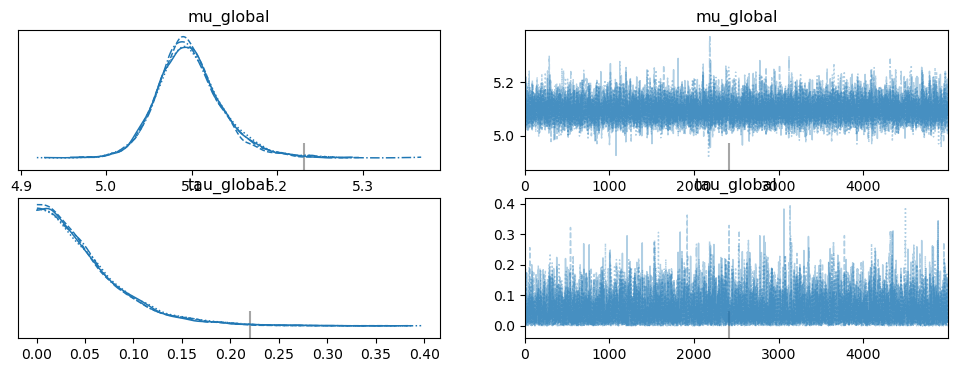

In [214]:
az.plot_trace(trace, var_names=["mu_global", "tau_global"])

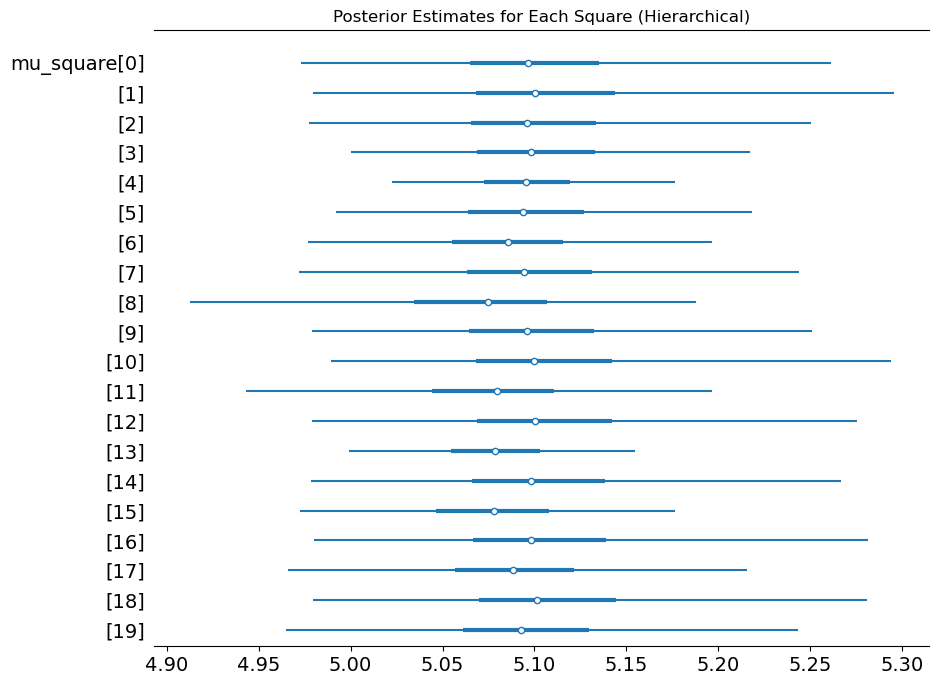

In [215]:
import matplotlib.pyplot as plt

# Plotting the 20 square means
az.plot_forest(trace, var_names=["mu_square"], combined=True, figsize=(10, 8))
#plt.axvline(5.10, color='red', linestyle='--', label='Prior Global Mean')
plt.title("Posterior Estimates for Each Square (Hierarchical)")
plt.show()

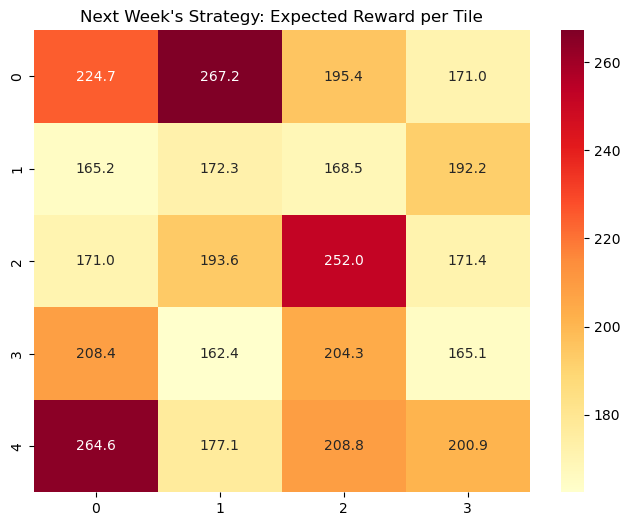

In [216]:
import numpy as np
import seaborn as sns

def plot_reward_heatmap(trace):
    # Extract posterior samples
    mu_samples = trace.posterior["mu_square"].values
    sigma_samples = trace.posterior["sigma_square"].values
    
    # Calculate Expected Value in real terms
    # (exp(mu + sigma^2 / 2) is the mean of a Log-Normal)
    ev_samples = np.exp(mu_samples + (sigma_samples**2) / 2)
    
    # Take the mean of all samples to get a single point estimate per square
    # We average across chains (axis 0) and draws (axis 1)
    ev_grid = ev_samples.mean(axis=(0, 1)).reshape(5, 4)
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(ev_grid, annot=True, fmt=".1f", cmap="YlOrRd")
    plt.title("Next Week's Strategy: Expected Reward per Tile")
    plt.show()

plot_reward_heatmap(trace)

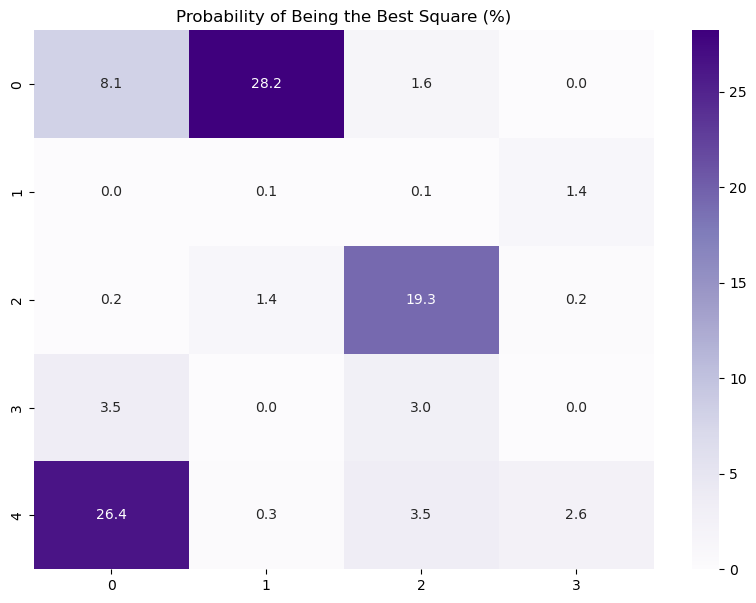

In [217]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pbb_heatmap(trace):
    # 1. Get all samples for all 20 squares (converted back from log-space)
    # Shape will be (Chains * Draws, 20)
    mu_samples = trace.posterior["mu_square"].values.reshape(-1, 20)
    sigma_samples = trace.posterior["sigma_square"].values.reshape(-1, 20)
    
    # Calculate Expected Value for every single MCMC sample
    ev_samples = np.exp(mu_samples + (sigma_samples**2) / 2)
    
    # 2. For each sample (row), find the index of the square with the max value
    best_square_indices = np.argmax(ev_samples, axis=1)
    
    # 3. Calculate the percentage of samples where each square was the 'winner'
    pbb = np.zeros(20)
    for idx in best_square_indices:
        pbb[idx] += 1
    pbb = (pbb / len(best_square_indices)) * 100 # Convert to %
    
    # 4. Plot
    plt.figure(figsize=(10, 7))
    sns.heatmap(pbb.reshape(5, 4), annot=True, fmt=".1f", cmap="Purples")
    plt.title("Probability of Being the Best Square (%)")
    plt.show()

plot_pbb_heatmap(trace)